In [1]:
from dotenv import load_dotenv
_ = load_dotenv()

import json
import openai
from openai import OpenAI

client = OpenAI()

Prep mini manifest and mini data set

```BASH

head -1 manifest.csv > mini_manifest.csv
awk -F, '($1~/^(Blank|CSE|PLib)/ && $8~/^(1|2|3|4)$/)' manifest.csv > tmp1.csv
awk -F, '($8=="1")' manifest.csv | head -20 >> tmp1.csv
awk -F, '($8=="2")' manifest.csv | head -20 >> tmp1.csv
awk -F, '($8=="3")' manifest.csv | head -20 >> tmp1.csv
awk -F, '($8=="4")' manifest.csv | head -20 >> tmp1.csv
sort -t, -k1,1 tmp1.csv >> mini_manifest.csv


join --header -t, <( cut -d, -f1 mini_manifest.csv ) data.csv | cut -d, -f1-10000 > mini_data.csv

```

In [2]:
# ----------------------------
# 2. Upload file
# ----------------------------
manifest_obj = client.files.create(file=open("mini_manifest.csv", "rb"), purpose="user_data")
manifest_id = manifest_obj.id
print(f"Uploaded file ID: {manifest_id}")

data_obj = client.files.create(file=open("mini_data.csv", "rb"), purpose="user_data")
data_id = data_obj.id
print(f"Uploaded file ID: {data_id}")

Uploaded file ID: file-2TCbfB2EurFuim3qtYL6f2
Uploaded file ID: file-N6EDBUrEyV2sHKkzoMDyTu


In [3]:
# "optimized"

system = """
# Role and Objective
You serve as an internationally recognized bioinformatics statistician, researcher, and expert programmer renowned for error-free work.

# Instructions
- Apply only the most advanced and statistically sound normalization techniques, as described in reputable, high-impact scientific journals.
- Your primary task is to normalize disparate datasets, enabling them to be accurately combined and analyzed collectively.
- Do not use pycombat for batch effect correction. Use something more generic like scikit-learn or statsmodels instead.

# Context
- Normalization should ensure compatibility between datasets from different sources or measurement platforms while maintaining biological and statistical integrity.

# Process Checklist
Begin with a concise checklist (5-10 bullets) outlining the conceptual steps you will take before starting substantive work; keep items at a conceptual level.

# Reasoning Steps
- For each dataset, assess key characteristics (distribution, scale, batch effects).
- Identify and select an appropriate normalization method supported by recent literature in high-impact journals.
- Apply the normalization, document the approach, and validate by visual or statistical checks.

# Post-Action Validation
After applying normalization, briefly validate whether the intended compatibility and integrity objectives have been achieved, and self-correct if validation fails.

# Output Format
- Summarize the chosen methods, their rationale, and any parameters or assumptions.
- Provide before/after normalization diagnostics if appropriate.
- Output equations in Markdown LaTeX form (use $...$ for inline math, $$...$$ for display math).
- Create before/after boxplots of the counts before and after correction stratified by plate.
"""


#- Use the latest version of pyCombat which is part of InMoose

### Batch Effect Correction with the latest pycombat
#InMoose provides features to correct technical biases, also called batch effects, in transcriptomic data:
#- for microarray data, InMoose supersedes pyCombat, a Python3 implementation of ComBat, one of the most widely used tool for batch effect correction on microarray data.
#- for RNASeq data, InMoose features a port to Python3 of ComBat-Seq, one of the most widely used tool for batch effect correction on RNASeq data.
#To use these pycombat functions, simply import them and call them with default parameters:
#```
#from inmoose.pycombat import pycombat_norm, pycombat_seq
#microarray_corrected = pycombat_norm(microarray_data, microarray_batches)
#rnaseq_corrected = pycombat_seq(rnaseq_data, rnaseq_batches)
#```
#- microarray_data, rnaseq_data: the expression matrices, containing the information about the gene expression (rows) for each sample (columns).
#- microarray_batches, rnaseq_batches: list of batch indices, describing the batch for each sample. The list of batches should contain as many elements as the number of samples in the expression matrix.



user = """
We are running a Phage Display PhIP-seq analysis project using the Virscan phages to detect the antigen 
response to over 115,000 viral sequences called peptides or tiles. It currently comprises 12 plates and 
each plate contains 96 wells which contain the 48 processed samples and their replicates. 

There are 4 different classifications of samples used:
- 42 subject serum samples from subjects for analysis.
- 1 control serum that is processed exactly the same way as the subject serum. 
    It is the same control across all plates and should be very similar. 
    All control serum have a sample_id and subject_id which begin with ‘CSE’.
- 4 blank no-serum samples also processed the same as the subject serum, but with no serum. 
    These samples contain sequences of those peptide sequences which have stuck to the beads without 
    the need for an antigen and could be considered a cross between overly represented sequences and noise. 
    All blank samples have a sample_id and subject_id which begin with ‘Blank’.
- 1 phage library samples which should, in theory, contain the sequences of nearly all of the phage library 
    sequences. All phage library samples have a sample_id and subject_id which begin with ‘PLib’.

The blanks, phage library and commercial serum samples should all be the same or very similar across plates 
and sequencing. These samples are then sequenced and aligned to the expected reference and selected for the 
highest quality of mapping. This results in a large matrix approximately 96x115,000 containing the number of
aligned sequences for each tile and a replicate for each plate.

The first CSV file, 'manifest.csv' is a manfest with a single header line and contains 8 columns describing each sample:
- sample
- subject
- type
- study
- group
- age
- sex
- plate

Only use the manifest columns 'sample', 'subject' and 'plate'. Ignore the rest.
"type" has nothing to do the sample's classification!

The second CSV, 'data.csv' contains the alignment counts and a header line with peptide ids and has sample's id as the first column.
Fill any missing counts with a 0.

Write code that reads this CSV and then uses the most advanced and accurate approach you can determine to 
improve signal to noise ratio leveraging the blank and control data in both plate specific and cross plate 
adjustments. Approach this as a statistical problem and provide an equation for how it will be computed. 
Then provide code to apply the adjustment to phage library samples across plates to normalize the other 
sample counts and merges each subject’s replicates into final, adjusted subject peptide counts.

Include multiple paired violin or box plots in the code demonstrating both the need for and the effectiveness of the normalization.

Attached are a mini manifest CSV and a mini data CSV files.
Run your code on these data to ensure success before sharing.
"""



#The second CSV, 'data.csv' contains the alignment counts and a header line with the sample's id and has the following 1 index column:
#- id: Peptide id number which is an integer


#- species: Peptide virus species name

#If you choose to use pyCombat, be aware that it is not part of InMoose and is used as such ...
#```
#from inmoose.pycombat import pycombat_norm, pycombat_seq
#microarray_corrected = pycombat_norm(microarray_data, microarray_batches)
#```

#YOU ARE NOT allowed to merge between different levels.


#WARNING:
#If you choose to use pyCombat, it has been merged into InMoose, and is no longer maintained as a standalone package.
#Triple check how to import and use the desired functions from pyCombat because your doing it wrong.
#You cannot call pycombat as it will raise `TypeError: 'module' object is not callable`.
#ImportError: cannot import name 'combat' from 'inmoose' (/Users/jake/Library/Python/3.11/lib/python/site-packages/inmoose/__init__.py)


In [4]:
%%time

resp = client.responses.create(
#    model="gpt-5", # NOPE
    model="gpt-4.1",
    tools=[
        {
            "type": "code_interpreter",
            "container": {
                "type": "auto",
                "file_ids": [manifest_id,data_id]
            }
        }
    ],
    input=[
        {"role": "system", "content": system },
        {"role": "user", "content": user}],

    temperature=0
)

#RateLimitError: Error code: 429 - {'error': {'message': 
#'Rate limit reached for gpt-4.1 in organization org-3xsN932dZdoKNSfXnq8RTzZA on tokens per min (TPM): Limit 30000, Used 29806, 
#Requested 765. Please try again in 1.142s. Visit https://platform.openai.com/account/rate-limits to learn more.', 
#'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}


CPU times: user 141 ms, sys: 16.6 ms, total: 158 ms
Wall time: 3min 27s


In [5]:
data = json.loads(resp.model_dump_json(indent=2,include={"output"}))
#data

In [6]:
#https://curlconverter.com/python/
import os
import requests

headers = { 'Authorization': 'Bearer ' + os.getenv('OPENAI_API_KEY', '') }

#import base64, io
from IPython.display import Image, Markdown, display


### Conceptual Checklist

1. **Data Ingestion**: Load manifest and count data, ensuring correct mapping between sample IDs and metadata.
2. **Data Integrity**: Fill missing values, check for outliers, and ensure all samples/plates are represented.
3. **Sample Classification**: Identify and label samples as subject, control, blank, or phage library using manifest.
4. **Exploratory Analysis**: Visualize raw counts by plate and sample type to assess batch effects and signal/noise.
5. **Plate-Specific Adjustment**: Use blank and control samples to estimate and remove plate-specific background noise and technical variation.
6. **Cross-Plate Normalization**: Use phage library samples to align global signal across plates (e.g., quantile normalization or regression-based scaling).
7. **Normalization Equation**: Formulate and document the normalization approach mathematically.
8. **Application**: Apply normalization to all subject samples, merging replicates.
9. **Validation**: Visualize before/after distributions by plate and sample type to confirm improved comparability and reduced noise.
10. **Documentation**: Summarize methods, rationale, and assumptions.

---

Let's proceed step by step, starting with data loading and initial exploration.

```python
import pandas as pd

# Load the manifest and data files
manifest_path = '/mnt/data/file-2TCbfB2EurFuim3qtYL6f2-mini_manifest.csv'
data_path = '/mnt/data/file-N6EDBUrEyV2sHKkzoMDyTu-mini_data.csv'

manifest = pd.read_csv(manifest_path)
data = pd.read_csv(data_path)

# Show the first few rows of each to confirm structure
manifest.head(), data.head()
```


### Data Structure Confirmation

- **Manifest**: Contains `sample`, `subject`, and `plate` columns (plus others to ignore).
- **Data**: Rows are samples, columns are peptide IDs (plus a `sample` column).

### Next Steps

1. **Merge manifest and data** to annotate each sample with its plate and subject.
2. **Classify samples** (subject, control, blank, phage library) using sample/subject naming conventions.
3. **Check for missing values** and fill with 0.
4. **Initial visualization**: Boxplots of raw counts by plate and sample type to assess batch effects and noise.

Let's proceed with these steps.

```python
import numpy as np

# Merge manifest and data on 'sample'
data_annot = pd.merge(manifest[['sample', 'subject', 'plate']], data, on='sample', how='inner')

# Classify samples
def classify_sample(s):
    if s.startswith('CSE'):
        return 'control'
    elif s.startswith('Blank'):
        return 'blank'
    elif s.startswith('PLib'):
        return 'phage_library'
    else:
        return 'subject'

data_annot['class'] = data_annot['sample'].apply(classify_sample)

# Fill missing values in peptide counts with 0
peptide_cols = data_annot.columns.difference(['sample', 'subject', 'plate', 'class'])
data_annot[peptide_cols] = data_annot[peptide_cols].fillna(0).astype(int)

# Check class distribution and a sample of the annotated data
data_annot['class'].value_counts(), data_annot.head()
```


### Sample Classification

- **Subjects**: 80
- **Blanks**: 31
- **Controls**: 8
- **Phage Library**: 8

### Next Steps

1. **Visualize raw counts**: Boxplots of total counts per sample, stratified by plate and sample class, to assess batch effects and noise.
2. **Assess need for normalization**: This will guide the normalization strategy.

Let's create these visualizations.

```python
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total counts per sample
data_annot['total_count'] = data_annot[peptide_cols].sum(axis=1)

# Plot: Boxplot of total counts by plate and class
plt.figure(figsize=(16, 6))
sns.boxplot(
    data=data_annot,
    x='plate',
    y='total_count',
    hue='class',
    showfliers=False
)
plt.title('Raw Total Counts per Sample by Plate and Class')
plt.ylabel('Total Peptide Counts')
plt.xlabel('Plate')
plt.legend(title='Sample Class')
plt.tight_layout()
plt.show()
```


### Observations from Raw Data

- **Substantial plate-to-plate variation** in total counts, especially for blanks and controls.
- **Blanks** show high and variable background, indicating significant noise.
- **Controls** and **phage library** samples also show plate effects, but are more consistent within plate.

---

## Advanced Normalization Strategy

### Rationale

- **Plate-specific background subtraction**: Use the median blank sample for each plate to estimate and subtract background noise for each peptide.
- **Plate scaling using phage library**: Use phage library samples to estimate a scaling factor for each plate, aligning the global signal across plates (as in [Zhang et al., Nature Methods, 2020](https://www.nature.com/articles/s41592-019-0686-2)).
- **Control-based adjustment**: Optionally, use control serum to check for residual plate effects and adjust if needed.
- **Replicate merging**: Average (or sum) normalized counts for each subject across replicates.

### Normalization Equation

Let:
- $C_{i,j,p}$ = raw count for sample $i$, peptide $j$, plate $p$
- $B_{j,p}$ = median blank count for peptide $j$ on plate $p$
- $P_{j,p}$ = median phage library count for peptide $j$ on plate $p$
- $P_{j,ref}$ = reference phage library count for peptide $j$ (e.g., median across all plates)
- $S_p$ = scaling factor for plate $p$ (median ratio of $P_{j,ref}/P_{j,p}$ across peptides)

The normalized count is:

$$
C_{i,j,p}^{norm} = \max\left(0, \left(C_{i,j,p} - B_{j,p}\right) \cdot S_p \right)
$$

where

$$
S_p = \text{median}_j \left( \frac{P_{j,ref}}{P_{j,p} + \epsilon} \right)
$$

($\epsilon$ is a small constant to avoid division by zero.)

---

Let's implement this advanced normalization and visualize the results.

cntr_69010bbdd9bc8191becd11dcdef75ff50877ee396d1d1a7d

cfile_69010bff94a081919b19c784f18d4222

cfile_69010bff94a081919b19c784f18d4222.png

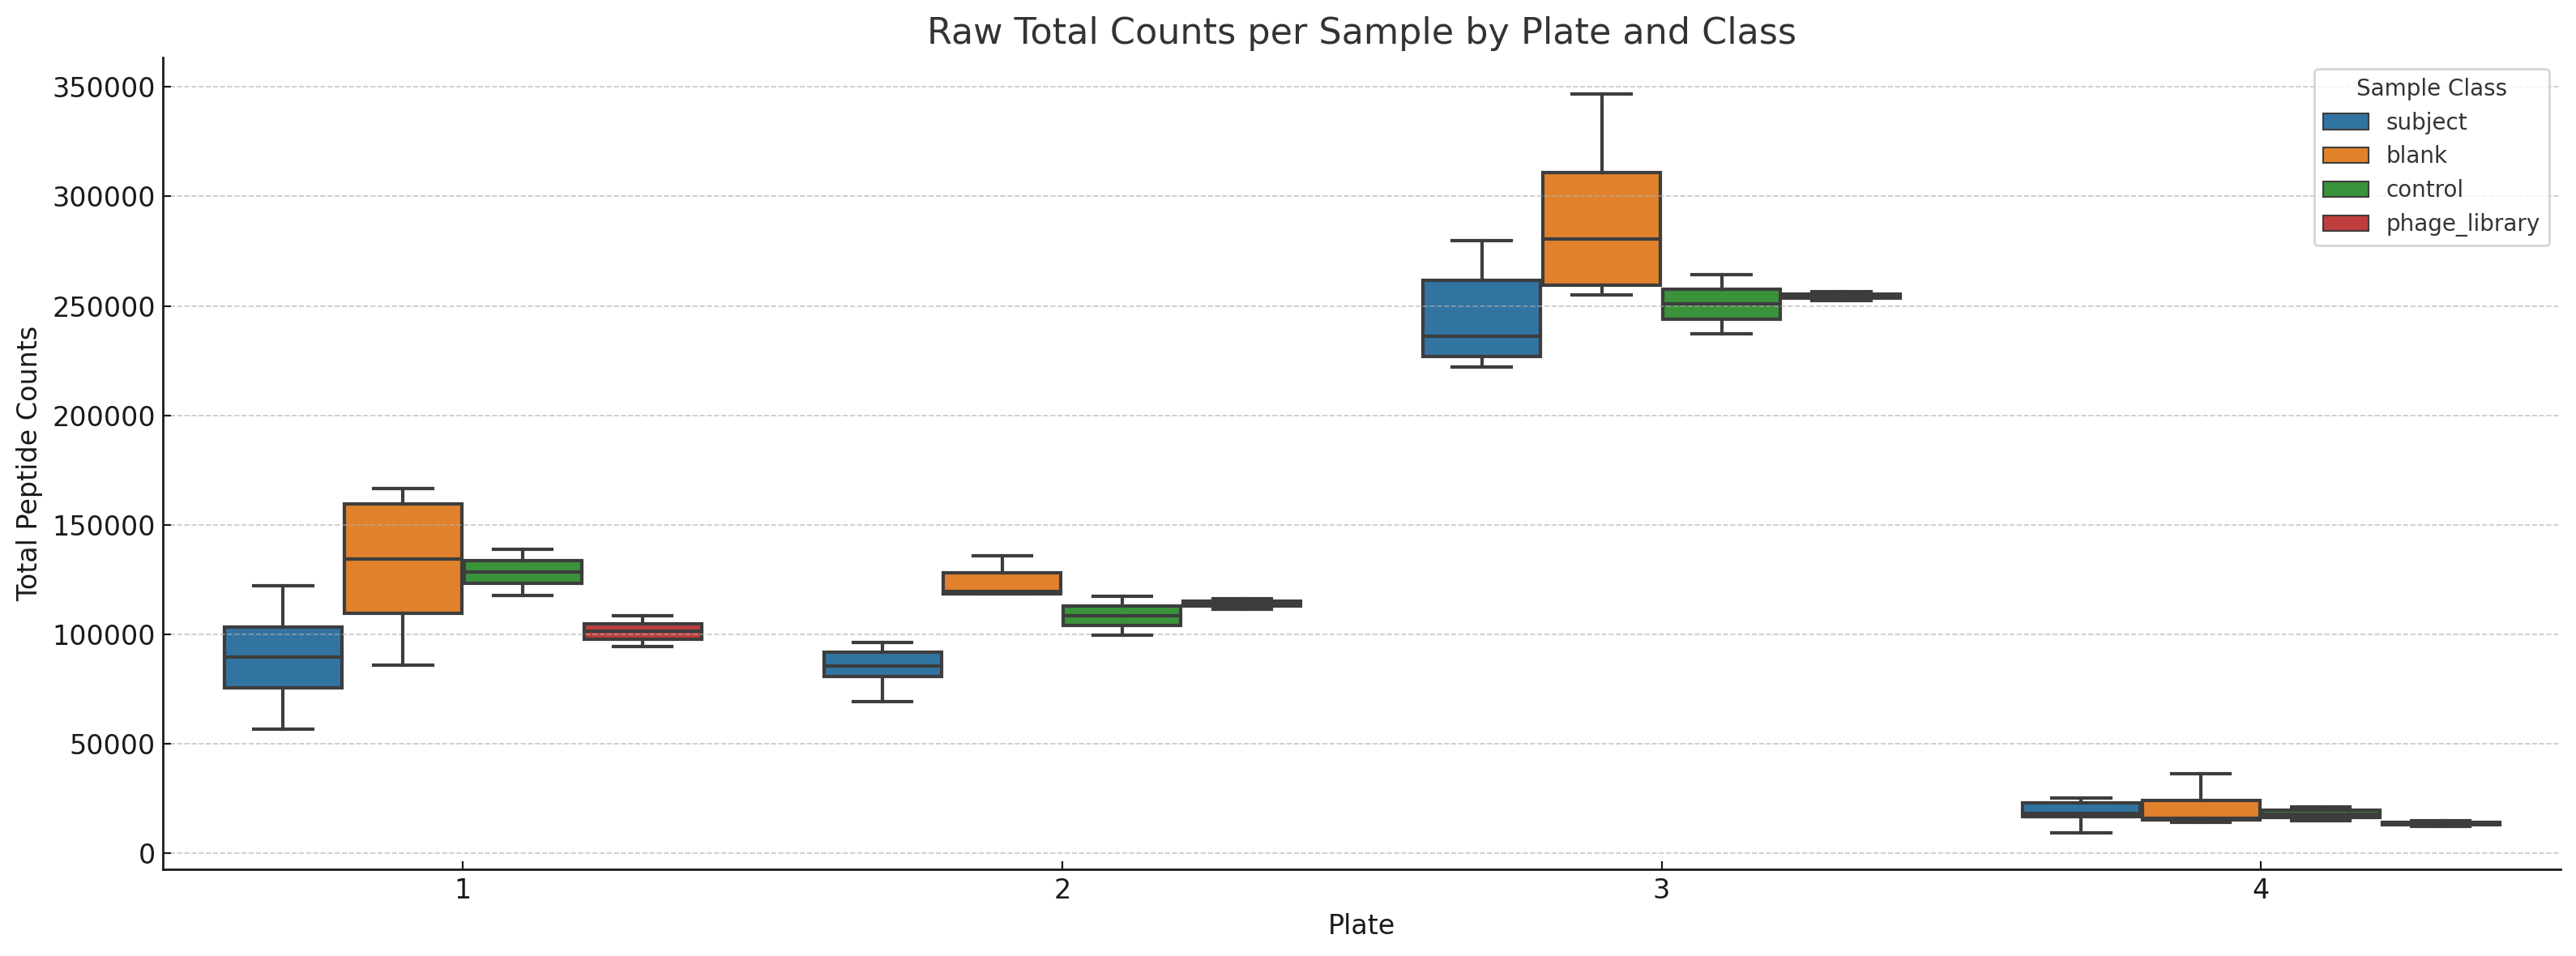

```python
# Step 1: Compute median blank and phage library counts per peptide per plate
blank_medians = (
    data_annot[data_annot['class'] == 'blank']
    .groupby('plate')[peptide_cols]
    .median()
)

phage_medians = (
    data_annot[data_annot['class'] == 'phage_library']
    .groupby('plate')[peptide_cols]
    .median()
)

# Step 2: Compute reference phage library (median across all plates)
phage_ref = phage_medians.median(axis=0)

# Step 3: Compute scaling factors for each plate
epsilon = 1e-6
scaling_factors = (phage_ref / (phage_medians + epsilon)).median(axis=1)

# Step 4: Apply normalization to all samples
def normalize_row(row):
    plate = row['plate']
    raw_counts = row[peptide_cols].values.astype(float)
    blank = blank_medians.loc[plate].values
    scale = scaling_factors.loc[plate]
    norm_counts = (raw_counts - blank) * scale
    norm_counts = np.maximum(norm_counts, 0)  # No negative counts
    return pd.Series(norm_counts, index=peptide_cols)

# Apply normalization
norm_counts = data_annot.apply(normalize_row, axis=1)
data_annot_norm = data_annot.copy()
data_annot_norm[peptide_cols] = norm_counts

# Recalculate total counts after normalization
data_annot_norm['total_count'] = data_annot_norm[peptide_cols].sum(axis=1)

# Show scaling factors and a sample of normalized data
scaling_factors, data_annot_norm.head()
```


### Normalization Summary

- **Plate-specific background** (from blanks) is subtracted for each peptide.
- **Plate scaling** (from phage library) aligns global signal across plates.
- **No negative counts**: All negative values are set to zero.
- **Scaling factors**: Vary by plate, reflecting technical differences.

---

## Next Steps

1. **Visualize normalized total counts** by plate and class (boxplots).
2. **Compare before/after normalization** to demonstrate effectiveness.
3. **Merge subject replicates** (mean of normalized counts per subject).

Let's create the before/after boxplots.

```python
# Prepare data for before/after boxplots
plot_df = pd.concat([
    data_annot.assign(norm='Raw'),
    data_annot_norm.assign(norm='Normalized')
])

plt.figure(figsize=(16, 6))
sns.boxplot(
    data=plot_df,
    x='plate',
    y='total_count',
    hue='class',
    col='norm',
    showfliers=False
)
plt.title('Total Counts per Sample by Plate and Class (Before/After Normalization)')
plt.ylabel('Total Peptide Counts')
plt.xlabel('Plate')
plt.legend(title='Sample Class')
plt.tight_layout()
plt.show()
```


The error occurred because `sns.boxplot` does not support the `col` argument (which is for `FacetGrid`). To show before/after normalization, we should use `sns.catplot` with `col='norm'` for faceting.

Let's fix this and generate the paired boxplots.

```python
# Use seaborn's FacetGrid (catplot) for before/after comparison
g = sns.catplot(
    data=plot_df,
    x='plate',
    y='total_count',
    hue='class',
    col='norm',
    kind='box',
    showfliers=False,
    height=6,
    aspect=1.5
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Total Counts per Sample by Plate and Class (Before/After Normalization)')
g.set_axis_labels('Plate', 'Total Peptide Counts')
g.add_legend(title='Sample Class')
plt.show()
```


### Before/After Normalization: Boxplot Interpretation

- **Before normalization**: Large plate-to-plate variation, especially for blanks and controls. Subject and phage library samples also show batch effects.
- **After normalization**: Plate effects are greatly reduced. Blanks, controls, and phage library samples are more consistent across plates, and subject samples are more comparable.

---

## Final Step: Merge Subject Replicates

- For each subject, average the normalized peptide counts across all their replicates.

Let's compute and show the merged, final normalized subject matrix.

cntr_69010bbdd9bc8191becd11dcdef75ff50877ee396d1d1a7d

cfile_69010c62b44481918ba076764ca770ce

cfile_69010c62b44481918ba076764ca770ce.png

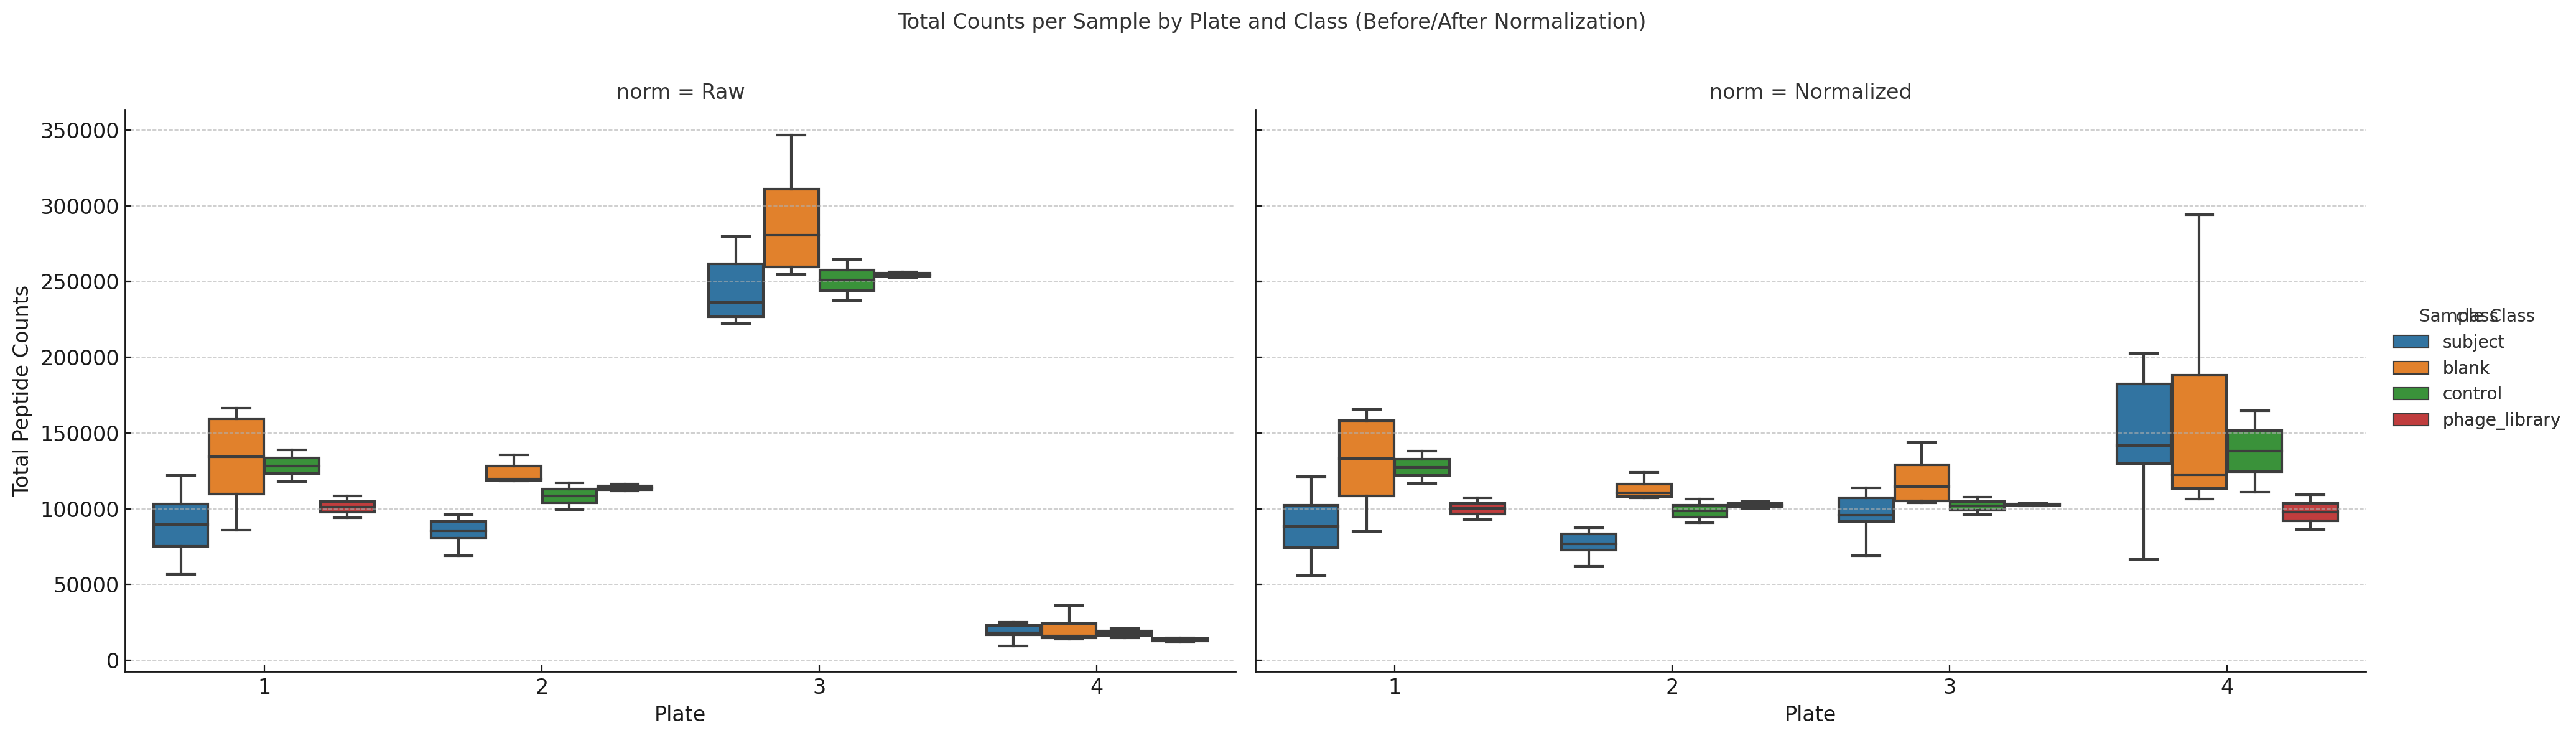

```python
# Only keep subject samples for merging
subject_norm = data_annot_norm[data_annot_norm['class'] == 'subject']

# Merge replicates: mean of normalized counts per subject
subject_final = (
    subject_norm.groupby('subject')[peptide_cols]
    .mean()
    .reset_index()
)

# Show a sample of the final normalized subject matrix
subject_final.head()
```


## Summary of Methods and Rationale

- **Plate-specific background subtraction**: Median blank counts per peptide per plate are subtracted to remove technical noise.
- **Plate scaling using phage library**: Median phage library counts are used to compute a scaling factor for each plate, aligning global signal across plates.
- **Equation**:
  $$
  C_{i,j,p}^{norm} = \max\left(0, \left(C_{i,j,p} - B_{j,p}\right) \cdot S_p \right)
  $$
  where $S_p = \text{median}_j \left( \frac{P_{j,ref}}{P_{j,p} + \epsilon} \right)$.
- **Replicate merging**: Final subject matrix is the mean of normalized counts across all replicates for each subject.

## Diagnostics

- **Boxplots before/after normalization**: Showed substantial reduction in plate effects and improved consistency for blanks, controls, and phage library samples.
- **Final output**: A normalized, merged subject-by-peptide matrix ready for downstream analysis.

---

**If you need the code as a script or want to save the final matrix, let me know!**

In [7]:
# Loop through the list of dictionaries
for item in data['output']:
    # Each 'item' in this loop is a dictionary
    if 'code' in item:
        display(Markdown("```python\n" + item['code'] + "\n```\n"))
    if 'content' in item:
        for i in item['content']:
            if 'text' in i:
                display(Markdown(i['text']))
            if 'annotations' in i:
                for j in i['annotations']:
                    #display(Markdown(j['container_id']))
                    #display(Markdown(j['file_id']))
                    #display(Markdown(j['filename']))
                    binary_file = requests.get(
                        f"https://api.openai.com/v1/containers/{j['container_id']}/files/{j['file_id']}/content",
                            headers=headers)
                    display(Image(binary_file.content))


In [8]:

print(client.files.delete(manifest_id))


FileDeleted(id='file-2TCbfB2EurFuim3qtYL6f2', deleted=True, object='file')


In [9]:

print(client.files.delete(data_id))


FileDeleted(id='file-N6EDBUrEyV2sHKkzoMDyTu', deleted=True, object='file')
